# Polarization analysis of Arase high-frequency EMIC waves

This companion to [`arase_gannon_high_frequency_emic_waves.ipynb`](./arase_gannon_high_frequency_emic_waves.ipynb) examines the polarization of the unusually high-frequency electromagnetic ion cyclotron (EMIC) waves observed by Arase late on 11 May 2024.

The introductory notebook established the event context, constructed a gap-aware spectrum, and overlaid local ion gyrofrequencies. Here we add the steps needed by PySPEDAS `twavpol`:

1. use `avg_data`, `time_interpolate`, and `subtract` to establish the ambient and wave fields;
2. rotate the three-component waveform into a right-handed mean-field-aligned (MFA) system;
3. calculate wave power, degree of polarization, signed ellipticity, helicity, and wave-normal angle; and
4. combine the power and gyrofrequency tplot variables and display the polarization products with `tplot`.

The scientific reference is [Jun et al. (2025), *Arase In Situ Observations of High-Frequency Electromagnetic Ion Cyclotron (EMIC) Waves in Regions Close to the Earth During the May 2024 Storm*](https://doi.org/10.1029/2024GL112489), especially Figures 3 and 4. Their analysis used the 256 Hz MGF waveform in a mean-field-aligned system with 16 s analysis windows stepped by 5 s. This notebook follows that cadence but is an instructional analysis, not an exact reproduction.

> **Date note:** although the published Figure 3 caption says May 10–11, the surrounding text and the data identify the event as May 11–12, 2024.


## 1. What the polarization quantities mean

`twavpol` forms the complex spectral (covariance) matrix of the three magnetic components. It derives:

- **power spectral density**: total magnetic wave power, in nT$^2$/Hz for nT input;
- **degree of polarization**: 0 for poorly organized/noise-like fluctuations and 1 for a pure polarization state;
- **wave-normal angle**: angle between the minimum-variance direction and the MFA $+Z$ direction, interpreted as the background-field direction for a plane wave;
- **ellipticity**: minor/major polarization-ellipse axis ratio in the plane perpendicular to MFA $+Z$; in the convention used here, negative is left-handed about $+\mathbf{B}_0$, zero is linear, and positive is right-handed; and
- **helicity magnitude**: an unsigned ellipse ratio referenced to the minimum-variance direction.

Polarization values are not meaningful where wave power is negligible. We will therefore apply an explicit power/coherence display mask rather than interpreting every colored pixel.

## 2. Imports and focused intervals

The 85 s processing interval provides padding around the one-minute interval emphasized by Jun et al. It begins after the short invalid-data block found in the companion notebook. We use PySPEDAS processing and plotting routines wherever they naturally fit, retaining NumPy for the explicit MFA vector rotation and threshold summaries.


In [1]:
# This line installs PySPEDAS so the notebook can be used in Google Colab.  You can comment
# it out or skip this cell if you already have a suitable PySPEDAS installation.

!pip install "pyspedas>=2.2.0"

In [2]:
%matplotlib inline

from datetime import datetime, timezone
from pprint import pprint

import pyspedas
from pyspedas import *
import numpy as np
from scipy.constants import elementary_charge, proton_mass

pyspedas.version()


30-Sep-26 13:16:55: pyspedas version: 2.2.0


In [3]:
load_trange = ["2024-05-11/23:55", "2024-05-11/23:58"]
processing_trange = ["2024-05-11/23:55:45", "2024-05-11/23:57:10"]
analysis_trange = ["2024-05-11/23:56", "2024-05-11/23:57"]

load_trange, processing_trange, analysis_trange

(['2024-05-11/23:55', '2024-05-11/23:58'],
 ['2024-05-11/23:55:45', '2024-05-11/23:57:10'],
 ['2024-05-11/23:56', '2024-05-11/23:57'])

## 3. Load and inspect the 256 Hz MGF waveform

The Arase MGF high-rate product is delivered in DSI coordinates. The loader downloads the 23 UT hourly file on a fresh run and reuses it from the local cache thereafter.

In [4]:
wave_vars = pyspedas.projects.erg.mgf(
    trange=load_trange,
    datatype="256hz",
    level="l2",
    coord="gse",
    time_clip=True,
)

wave_var = "erg_mgf_l2_mag_256hz_gse"
if wave_var not in wave_vars or get_data(wave_var) is None:
    raise RuntimeError(f"Expected waveform variable {wave_var!r} was not loaded")

30-Sep-26 13:16:55: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/256hz/2024/05/
30-Sep-26 13:17:01: Downloading https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/256hz/2024/05/erg_mgf_l2_256hz_gse_2024051123_v04.06.cdf to erg_data/satellite/erg/mgf/l2/256hz/2024/05/erg_mgf_l2_256hz_gse_2024051123_v04.06.cdf
30-Sep-26 13:17:11: Download of erg_data/satellite/erg/mgf/l2/256hz/2024/05/erg_mgf_l2_256hz_gse_2024051123_v04.06.cdf complete, 11.750 MB in 10.8 sec (1.088 MB/sec) (transfer_normal)
30-Sep-26 13:17:12: Variable erg_mgf_l2_date_time_256hz in file <cdflib.cdfread.CDF object at 0x3372ee2d0> has non-homogeneous unit values ['    yr', '    mo', '     d', '     h', '   min', '     s', '    ms', 'micros', '    ns']


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 256 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


In [5]:
wave_data = get_data(wave_var)
wave_metadata = get_data(wave_var, metadata=True)
wave_times = np.asarray(wave_data.times)
wave_b = np.asarray(wave_data.y, dtype=float)

dt = np.diff(wave_times)
short_dt = dt[dt < 0.02]
sample_dt = np.nanmedian(short_dt)
sample_rate = 1.0 / sample_dt
finite_rows = np.all(np.isfinite(wave_b), axis=1)
gap_threshold = 5.0 * sample_dt
gap_indices = np.flatnonzero(dt > gap_threshold)

print(f"Waveform shape: {wave_b.shape}")
print(f"Measured median cadence: {sample_dt * 1000:.4f} ms")
print(f"Effective sample rate: {sample_rate:.3f} Hz")
print(f"Finite three-component rows: {finite_rows.mean():.3%}")
print(f"Gaps larger than {gap_threshold:.4f} s: {len(gap_indices)}")
for i in gap_indices:
    t0 = datetime.fromtimestamp(wave_times[i], tz=timezone.utc)
    t1 = datetime.fromtimestamp(wave_times[i + 1], tz=timezone.utc)
    print(f"  {t0.isoformat()} to {t1.isoformat()} ({dt[i]:.3f} s)")

pprint({
    "units": wave_metadata.get("data_att", {}).get("units"),
    "coordinate_system_attribute": wave_metadata.get("data_att", {}).get("coord_sys"),
    "labels": wave_metadata.get("CDF", {}).get("LABELS"),
    "description": wave_metadata.get("CDF", {}).get("VATT", {}).get("CATDESC"),
})

Waveform shape: (46107, 3)
Measured median cadence: 3.9001 ms
Effective sample rate: 256.407 Hz
Finite three-component rows: 95.536%
Gaps larger than 0.0195 s: 0
{'coordinate_system_attribute': '',
 'description': 'B in GSE coordinates',
 'labels': ['Bx', 'By', 'Bz'],
 'units': 'nT'}


The generic coordinate-system attribute is blank in the current CDF, but both the variable name and description identify DSI coordinates. The requested processing interval lies entirely in a continuous block after the first short invalid interval.

## 4. Estimate $\mathbf{B}_0$ and isolate the wave field

As in the companion notebook, `avg_data(res=1.0)` supplies a one-second, non-overlapping ambient-field estimate. This is not a formal low-pass filter, but it follows the slowly changing several-thousand-nT field while averaging over many cycles of the 5–35 Hz waves.

`twavpol` requires uniform sampling. We therefore use `time_interpolate` to put both the waveform and ambient field on an exact 256 Hz grid over the already-continuous processing interval, then use PySPEDAS `subtract` to calculate $\delta\mathbf{B}=\mathbf{B}-\mathbf{B}_0$. The gap limits make the same recipe safe if the interval is extended: it will not silently interpolate through a real outage.


In [6]:
background_var = "arase_mgf_b0_1s_dsi"
wave_uniform_var = "arase_mgf_b_dsi_uniform"
background_uniform_var = "arase_mgf_b0_dsi_uniform"
wave_fluctuation_var = "arase_mgf_db_dsi_uniform"

avg_data(wave_var, res=1.0, newname=background_var)

processing_start, processing_stop = time_double(processing_trange)
uniform_sample_rate = 256.0
n_uniform = int(np.floor((processing_stop - processing_start) * uniform_sample_rate))
uniform_times = processing_start + np.arange(n_uniform) / uniform_sample_rate

time_interpolate(
    wave_var, uniform_times, newname=wave_uniform_var,
    method="linear", ignore_nans=True, max_gap_time=0.02,
    nan_extrapolate=True,
)
time_interpolate(
    background_var, uniform_times, newname=background_uniform_var,
    method="linear", ignore_nans=True, max_gap_time=2.0,
    nan_extrapolate=True,
)
subtract(wave_uniform_var, background_uniform_var, newname=wave_fluctuation_var)

uniform_wave_dsi = np.asarray(get_data(wave_fluctuation_var).y)
uniform_background_dsi = np.asarray(get_data(background_uniform_var).y)

if len(uniform_times) < 4096 or not np.all(np.isfinite(uniform_wave_dsi)):
    raise RuntimeError("The requested polarization interval is not continuously covered")

print("Uniform samples in processing interval:", len(uniform_times))
print("Uniform cadence [ms]:", 1000.0 / uniform_sample_rate)
print("All waveform and background samples finite:",
      np.all(np.isfinite(uniform_wave_dsi)),
      np.all(np.isfinite(uniform_background_dsi)))


30-Sep-26 13:17:13: /Users/jwl/anaconda3/envs/pycharm_py312/lib/python3.12/site-packages/pyspedas/analysis/avg_data.py:181: RuntimeWarning: Mean of empty slice
  tmp = np.nan if isempty else np.nanmean(data[idx0, j])

30-Sep-26 13:17:13: avg_data was applied to: arase_mgf_b0_1s_dsi


Uniform samples in processing interval: 21760
Uniform cadence [ms]: 3.90625
All waveform and background samples finite: True True


## 5. Rotate into a right-handed mean-field-aligned system

Polarization quantities are most naturally interpreted in a coordinate system tied to the local ambient magnetic field. We use the uniformly sampled GSE ambient field to construct a field-aligned coordinate (FAC) transformation with PySPEDAS `fac_matrix_make`, then rotate the wave fluctuations with `tvector_rotate`.

The resulting **FAC-XGSE** system is defined by:

- $\hat{z}$ parallel to the ambient magnetic field $\mathbf{B}_0$;
- $\hat{x}$ along GSE-X projected onto the plane perpendicular to $\mathbf{B}_0$; and
- $\hat{y}=\hat{z}\times\hat{x}$.

This produces a right-handed system satisfying $\hat{x}\times\hat{y}=\hat{z}$. The first two components therefore describe perpendicular fluctuations, while the third component is parallel to the ambient field.

The Arase MGF files used here do not populate the generic tplot coordinate attribute, so we explicitly identify the interpolated variables as GSE before constructing the transformation matrix. This avoids treating a spacecraft-coordinate axis as though it were GSE-X.

`tvector_rotate` can interpolate a time-dependent rotation matrix to the vector timestamps when necessary. Here, both variables already use the same uniform 256 Hz grid, so no additional time interpolation is required.

The orientation of the two perpendicular axes establishes the sign convention for ellipticity. Total wave power, degree of polarization, and wave-normal angle should not depend strongly on a fixed rotation within the perpendicular plane, but signed polarization quantities must always be interpreted together with the stated FAC convention.

In [7]:
## Rotate into a right-handed mean-field-aligned system

# The Arase CDF coordinate attribute is blank, so attach the coordinate
# information explicitly before constructing the rotation matrix.
set_coords(background_uniform_var, "GSE")
set_coords(wave_fluctuation_var, "GSE")

fac_matrix_var = "arase_mgf_gse_to_fac_matrix"
mfa_var = "arase_mgf_db_mfa_uniform"

matrix_name = fac_matrix_make(
    background_uniform_var,
    other_dim="xgse",
    newname=fac_matrix_var,
)
if matrix_name is None:
    raise RuntimeError("fac_matrix_make did not create the FAC rotation matrix")

rotated_vars = tvector_rotate(
    fac_matrix_var,
    wave_fluctuation_var,
    newname=mfa_var,
)
if not rotated_vars or get_data(mfa_var) is None:
    raise RuntimeError("tvector_rotate did not create the MFA waveform")

wave_mfa = np.asarray(get_data(mfa_var).y)

options(mfa_var, "legend_names", ["perp-X", "perp-Y", "parallel"])
options(mfa_var, "ytitle", "Wave B")
options(mfa_var, "ysubtitle", "FAC-XGSE [nT]")

print("Input coordinates:", get_coords(wave_fluctuation_var))
print("Output coordinates:", get_coords(mfa_var))
print(
    "MFA RMS [perp-X, perp-Y, parallel] nT:",
    np.sqrt(np.mean(wave_mfa**2, axis=0)),
)

30-Sep-26 13:17:13: Setting coordinate system for arase_mgf_b0_dsi_uniform
30-Sep-26 13:17:13: Setting coordinate system for arase_mgf_db_dsi_uniform
30-Sep-26 13:17:13: Setting coordinate system for arase_mgf_db_mfa_uniform


Input coordinates: GSE
Output coordinates: FAC-XGSE
MFA RMS [perp-X, perp-Y, parallel] nT: [0.70357199 1.03248849 0.79736006]


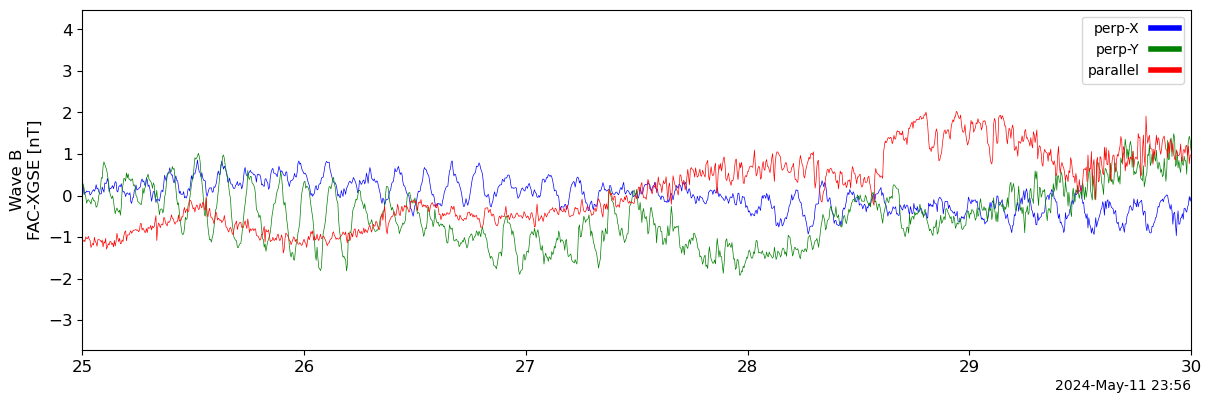

In [8]:
waveform_zoom = ["2024-05-11/23:56:25", "2024-05-11/23:56:30"]
tplot(mfa_var, trange=waveform_zoom, xsize=12, ysize=4)


The parallel RMS should be smaller than the two perpendicular RMS values for the strongest transverse EMIC fluctuations. The waveform alone is not sufficient to determine polarization; the relative phases between components enter through the complex spectral matrix.

## 6. Run PySPEDAS `twavpol`

The uniformly sampled MFA fluctuations are already stored as a tplot variable. We use a 4096-point FFT (16 s at 256 Hz), a 1280-point step (5 s), and seven-bin Hamming smoothing in frequency. The first two settings follow the cadence stated by Jun et al.; frequency smoothing stabilizes the spectral-matrix estimates.

`twavpol` assumes its input is already a right-handed field-aligned vector with $+Z$ along the ambient magnetic field. It does not perform this rotation for us.


In [9]:
nopfft = 4096
steplength = 1280
bin_freq = 7
prefix = "arase_emic_pol"

success = pyspedas.twavpol(
    mfa_var,
    prefix=prefix,
    nopfft=nopfft,
    steplength=steplength,
    bin_freq=bin_freq,
)
if success != 1:
    raise RuntimeError("twavpol did not complete successfully")

polarization_vars = [
    f"{prefix}_powspec",
    f"{prefix}_degpol",
    f"{prefix}_waveangle",
    f"{prefix}_elliptict",
    f"{prefix}_helict",
    f"{prefix}_pspec3_x",
    f"{prefix}_pspec3_y",
    f"{prefix}_pspec3_z",
]
missing = [name for name in polarization_vars if get_data(name) is None]
if missing:
    raise RuntimeError(f"Missing twavpol outputs: {missing}")

print("Created polarization variables:")
for name in polarization_vars:
    print(" ", name)


30-Sep-26 13:17:14: wavpol: File sampling frequency=256.0Hz
30-Sep-26 13:17:14: n_batches: 1
30-Sep-26 13:17:14: Total number of steps:17
30-Sep-26 13:17:14: Total number of possible FFT in the batch no 0 is:17.0
30-Sep-26 13:17:14: wavpol step: 0 
30-Sep-26 13:17:18: 
wavpol completed successfully
30-Sep-26 13:17:18: store_data: Data array for variable arase_emic_pol_pspec3 has 3 dimensions, but only 1 v_n keys plus time. Adding empty v_n keys.
30-Sep-26 13:17:18: arase_emic_pol_pspec3 does not contain coordinates for spectrogram plotting.  Continuing...


Created polarization variables:
  arase_emic_pol_powspec
  arase_emic_pol_degpol
  arase_emic_pol_waveangle
  arase_emic_pol_elliptict
  arase_emic_pol_helict
  arase_emic_pol_pspec3_x
  arase_emic_pol_pspec3_y
  arase_emic_pol_pspec3_z


## 7. Inspect and clean the returned arrays

`twavpol` returns angles in radians, ellipticity and helicity as dimensionless ratios, and degree of polarization from 0 to 1. In PySPEDAS 2.2.0 the routine can append a final bookkeeping row with zero total power, so we remove zero-power rows explicitly before plotting.

In [10]:
power_data = get_data(f"{prefix}_powspec")
pol_times_all = np.asarray(power_data.times)
frequencies = np.asarray(power_data.v)
power_all = np.asarray(power_data.y)
degree_all = np.asarray(get_data(f"{prefix}_degpol").y)
ellipticity_all = np.asarray(get_data(f"{prefix}_elliptict").y)
helicity_all = np.asarray(get_data(f"{prefix}_helict").y)
waveangle_all = np.degrees(np.asarray(get_data(f"{prefix}_waveangle").y))

valid_windows = (
    np.isfinite(pol_times_all)
    & (np.nansum(power_all, axis=1) > 0)
)
pol_times = pol_times_all[valid_windows]
power = power_all[valid_windows]
degree = degree_all[valid_windows]
ellipticity = ellipticity_all[valid_windows]
helicity = helicity_all[valid_windows]
waveangle = waveangle_all[valid_windows]
power_db = 10.0 * np.log10(np.where(power > 0, power, np.nan))

print(f"Valid analysis windows: {len(pol_times)} of {len(pol_times_all)}")
print(f"Frequency spacing: {frequencies[1] - frequencies[0]:.4f} Hz")
print(f"Window length: {nopfft / uniform_sample_rate:.2f} s")
print(f"Window step: {steplength / uniform_sample_rate:.2f} s")
print("Degree-of-polarization range:", np.nanmin(degree), np.nanmax(degree))
print("Ellipticity range:", np.nanmin(ellipticity), np.nanmax(ellipticity))
print("Wave-normal-angle range [deg]:",
      np.nanmin(waveangle), np.nanmax(waveangle))


Valid analysis windows: 17 of 17
Frequency spacing: 0.0625 Hz
Window length: 16.00 s
Window step: 5.00 s
Degree-of-polarization range: 0.0 0.9984984985795444
Ellipticity range: -0.8089615007980329 0.7866635012472857
Wave-normal-angle range [deg]: 0.06783261579150979 89.99729870130206


## 8. Apply a power and polarization-quality mask

The following thresholds are visualization choices, not physical event-selection criteria:

- power PSD at least $-25$ dB relative to 1 nT$^2$/Hz; and
- degree of polarization at least 0.7 for ellipticity and wave-normal interpretation.

We show degree of polarization wherever the power threshold is met. Ellipticity and wave-normal angle require both thresholds. Change these values in the exercises and check whether the scientific impression is robust.

In [11]:
power_threshold_db = -25.0
degree_threshold = 0.70

power_mask = power_db >= power_threshold_db
interpretation_mask = power_mask & (degree >= degree_threshold)

degree_display = np.where(power_mask, degree, np.nan)
ellipticity_display = np.where(interpretation_mask, ellipticity, np.nan)
waveangle_display = np.where(interpretation_mask, waveangle, np.nan)

# Store cleaned/masked products as tplot variables. Keep power linear and use
# tplot's logarithmic color scale; the threshold is still specified in dB.
power_display_var = "arase_emic_power_display"
degree_display_var = "arase_emic_degree_display"
ellipticity_display_var = "arase_emic_ellipticity_display"
waveangle_display_var = "arase_emic_waveangle_display"

for name, values in [
    (power_display_var, power),
    (degree_display_var, degree_display),
    (ellipticity_display_var, ellipticity_display),
    (waveangle_display_var, waveangle_display),
]:
    store_data(name, data={"x": pol_times, "y": values, "v": frequencies})
    options(name, "spec", True)
    options(name, "yrange", [2, 90])
    options(name, "ylog", True)
    options(name, "ysubtitle", "[Hz]")

options(power_display_var, "ytitle", "Power")
options(power_display_var, "zlog", True)
options(power_display_var, "zrange", [10**(-3.5), 10**0.5])
options(power_display_var, "Colormap", "turbo")
options(power_display_var, "ztitle", "PSD")
options(power_display_var, "zsubtitle", "[nT^2/Hz]")

options(degree_display_var, "ytitle", "Degree pol.")
options(degree_display_var, "zrange", [0.5, 1.0])
options(degree_display_var, "Colormap", "viridis")
options(degree_display_var, "ztitle", "Degree of pol.")
options(ellipticity_display_var, "ytitle", "Ellipticity")
options(ellipticity_display_var, "zrange", [-1, 1])
options(ellipticity_display_var, "Colormap", "bwr")
options(ellipticity_display_var, "ztitle", "Ellipticity")
options(waveangle_display_var, "ytitle", "Wave angle")
options(waveangle_display_var, "zrange", [0, 90])
options(waveangle_display_var, "Colormap", "viridis")
options(waveangle_display_var, "ztitle", "Wave-normal angle")
options(waveangle_display_var, "zsubtitle", "[deg]")

print("Pixels above power threshold:", np.count_nonzero(power_mask))
print("Pixels also above polarization threshold:",
      np.count_nonzero(interpretation_mask))


Pixels above power threshold: 3510
Pixels also above polarization threshold: 1270


## 9. Polarization overview with local gyrofrequencies

For context, we calculate local ion gyrofrequencies from the same one-second ambient-field estimate. Each gyrofrequency is stored as a line tplot variable. A pseudovariable combines those lines with the power spectrogram, while the masked polarization quantities occupy three additional tplot panels.


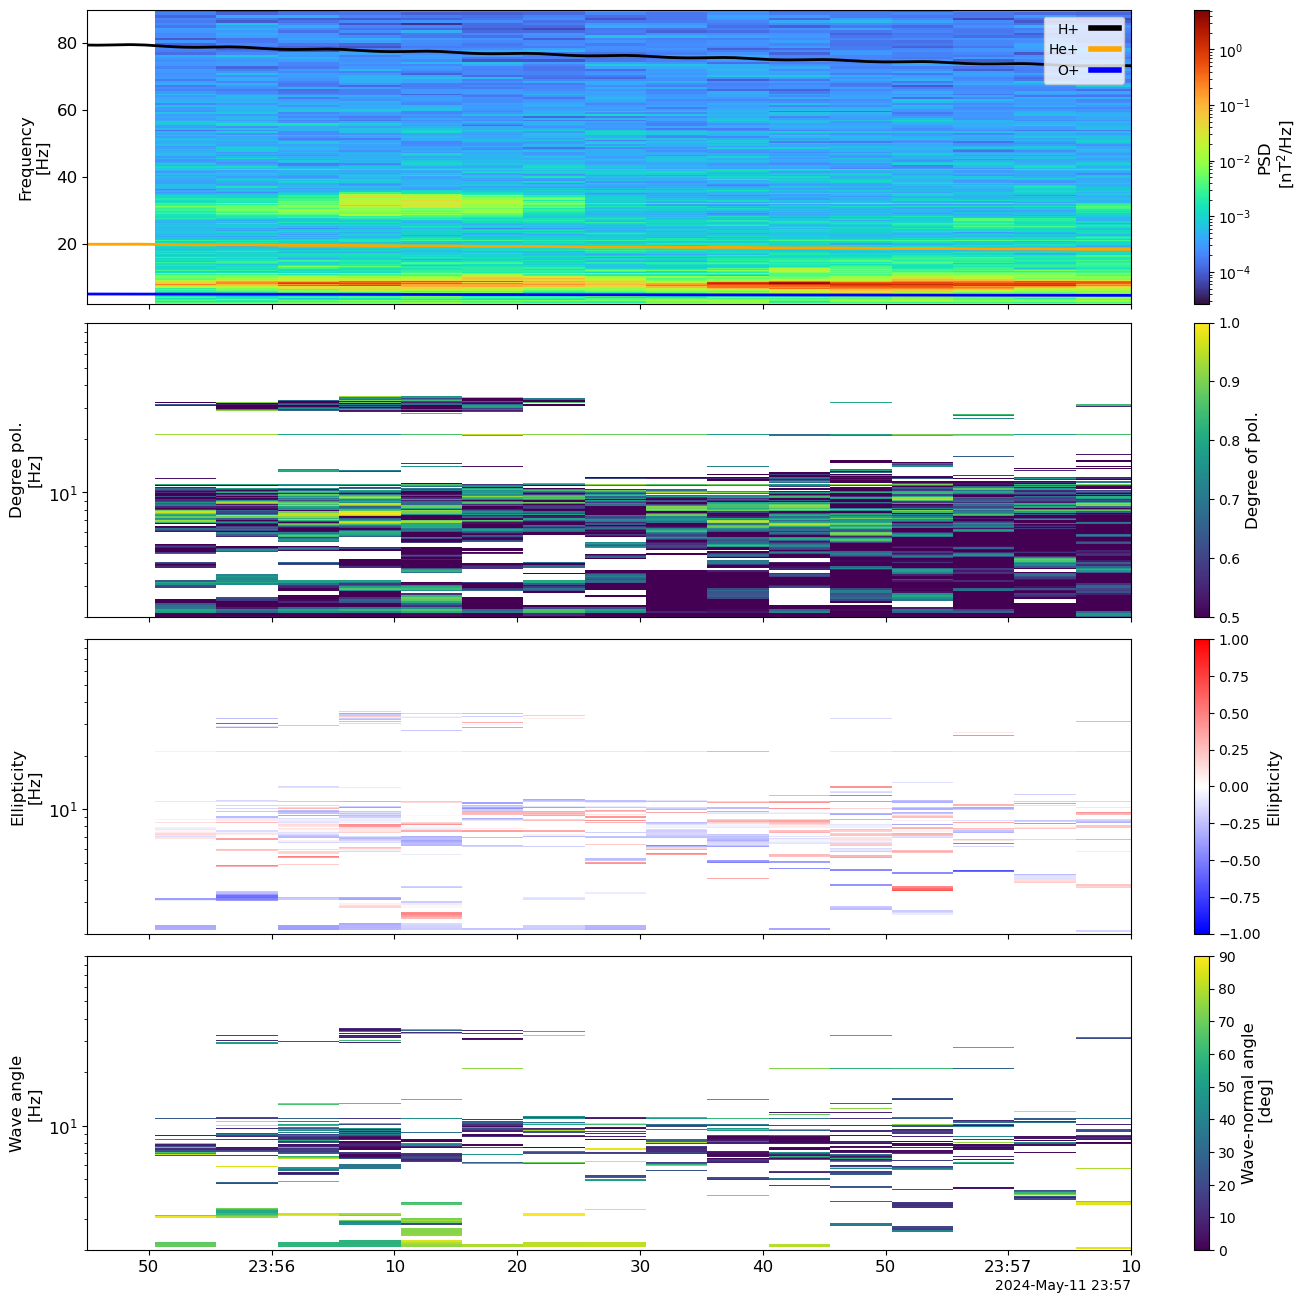

In [14]:
background_bmag_uniform = np.linalg.norm(uniform_background_dsi, axis=1)

def gyrofrequency_hz(b_nT, mass_number):
    b_tesla = np.asarray(b_nT) * 1e-9
    return elementary_charge * b_tesla / (2.0 * np.pi * mass_number * proton_mass)

gyro_vars = {
    "H+": ("arase_pol_f_cH", 1, "black"),
    "He+": ("arase_pol_f_cHe", 4, "orange"),
    "O+": ("arase_pol_f_cO", 16, "blue"),
}
for label, (name, mass_number, color) in gyro_vars.items():
    store_data(
        name,
        data={
            "x": uniform_times,
            "y": gyrofrequency_hz(background_bmag_uniform, mass_number),
        },
    )
    options(name, "color", color)
    options(name, "line_width", 2)
    options(name, "legend_names", [label])
    options(name, "ytitle", "Frequency")
    options(name, "ysubtitle", "[Hz]")

combined_power_var = "arase_emic_power_with_gyrofrequencies"
store_data(
    combined_power_var,
    data=[power_display_var] + [item[0] for item in gyro_vars.values()],
)
options(combined_power_var, "ytitle", "Frequency")
options(combined_power_var, "ysubtitle", "[Hz]")

tplot(
    [
        combined_power_var,
        degree_display_var,
        ellipticity_display_var,
        waveangle_display_var,
    ],
    trange=processing_trange,
    xsize=13,
    ysize=13,
)


Look for polarization structure only where the top panel shows wave power. The strongest 5–10 Hz emissions are highly polarized and include both nearly linear and left-handed pixels. The weaker 27–35 Hz packets are predominantly close to linear. The most coherent, high-power parts of both bands tend to have relatively small wave-normal angles, consistent with predominantly field-aligned propagation.

These statements are qualitative. A single spacecraft cannot determine the sign of the wave vector, and the estimated angle becomes unreliable when the spectral matrix is dominated by noise or multiple simultaneous wave modes.

## 10. Summarize the He$^+$ and H$^+$ bands

We now calculate simple medians over the paper's reported frequency ranges during 23:56–23:57 UT. Only pixels passing both display thresholds are included. The count is printed so a median based on very few pixels is not mistaken for a robust result.

In [13]:
analysis_start, analysis_stop = time_double(analysis_trange)
minute_mask = (pol_times >= analysis_start) & (pol_times < analysis_stop)

bands = {
    "He+ band": (5.0, 10.0),
    "H+ band": (27.0, 35.0),
}

print("Thresholded medians for 23:56–23:57 UT")
for label, (low, high) in bands.items():
    band_mask = (frequencies >= low) & (frequencies <= high)
    selected = minute_mask[:, None] & band_mask[None, :] & interpretation_mask
    if not np.any(selected):
        print(f"{label}: no pixels pass the thresholds")
        continue
    print(
        f"{label:8s}: N={np.count_nonzero(selected):3d}, "
        f"power={np.nanmedian(power_db[selected]):6.1f} dB, "
        f"degree={np.nanmedian(degree[selected]):.2f}, "
        f"ellipticity={np.nanmedian(ellipticity[selected]):+.2f}, "
        f"wave-normal={np.nanmedian(waveangle[selected]):.1f} deg, "
        f"helicity={np.nanmedian(helicity[selected]):.2f}"
    )

Thresholded medians for 23:56–23:57 UT
He+ band: N=427, power= -10.7 dB, degree=0.81, ellipticity=-0.06, wave-normal=14.3 deg, helicity=0.21
H+ band : N=155, power= -19.8 dB, degree=0.80, ellipticity=-0.10, wave-normal=21.0 deg, helicity=0.26


A median ellipticity near zero means that linear or mixed polarization dominates the selected pixels; it does **not** mean that every pixel is linear. Inspect the time-frequency panel to see the coexistence of signed patches. Likewise, the median wave-normal angle is a compact description of selected high-power pixels, not a replacement for the full distribution or an uncertainty analysis.

Jun et al. report linear H$^+$-band waves, mixed linear/left-handed He$^+$-band waves, and field-aligned wave normals near the event. The introductory `twavpol` results are qualitatively consistent with that interpretation.

## 11. Exercises

1. Change `power_threshold_db` from −25 dB to −30 and −20 dB. Which conclusions remain stable? Which medians change because weak pixels enter or leave the selection?
2. Change `degree_threshold` from 0.7 to 0.8. Does the H$^+$-band wave-normal estimate become more or less stable?
3. Repeat the analysis with `nopfft=2048` and `steplength=640`. Compare time resolution, frequency resolution, and the apparent patchiness of ellipticity.
4. Try `bin_freq=3` and `bin_freq=11`. Why does frequency smoothing alter degree of polarization and wave-normal estimates?
5. Plot `arase_emic_pol_pspec3_x`, `_y`, and `_z` with `tplot`. Which MFA component contains the least power in the strong 5–10 Hz packets?
6. Deliberately pass `arase_mgf_db_dsi_uniform` (the unrotated DSI fluctuations) to `twavpol`. Power is rotation invariant, but which derived quantities become physically ambiguous?
7. Extend the processing interval to later packets near 00:01 and 00:05 UT. Use `max_gap_time` to preserve gaps and analyze continuous intervals separately.
8. Change the ambient-field averaging resolution from 1 s to 0.5 or 2 s. Which polarization conclusions are stable?
9. Reverse one transverse MFA axis and rebuild the other axis so the system remains right-handed. Which signed quantity changes, and which invariant quantities do not?


## 12. Scientific takeaway

Wave power identifies where an emission exists; polarization analysis adds information about how the magnetic vector moves and how the wave may propagate. For the 23:56–23:57 UT Arase interval, the PySPEDAS spectral-matrix analysis shows organized, predominantly transverse EMIC emissions in both the 5–10 Hz He$^+$ band and the unusually high 27–35 Hz H$^+$ band. The strongest pixels are highly polarized and generally have relatively small wave-normal angles.

The workflow also demonstrates that polarization results require more preprocessing judgment than a power spectrum: data gaps must be isolated, time tags must be made uniform, the coordinate system must be right-handed and field aligned, and low-power pixels must be excluded from interpretation.

## Instructor notes and current caveats

- A fresh run downloads one hourly MGF 256 Hz file (about 15.6 MB in the archive version tested). The loader then clips it to the requested interval in memory.
- The current archive supplied MGF v04.06, whereas Jun et al. list v04.04. Small quantitative differences from the published figures are expected.
- `avg_data(res=1.0)` is a non-overlapping bin average, not a centered moving average or a formal low-pass filter. It is appropriate for this introductory 5–35 Hz analysis but should be varied as a sensitivity test in research work.
- The loaded interval includes the short invalid block before the processing interval. Its empty one-second bins remain NaN, and PySPEDAS 2.2.0 may print a benign `Mean of empty slice` warning while creating them.
- The native MGF time tags have small cadence variations. `time_interpolate` creates a nominal 256 Hz grid for `twavpol`; `max_gap_time` ensures the same code will retain real outages as NaNs rather than bridge them.
- The MFA basis uses a time-dependent measured $\mathbf{B}_0$ and a fixed projected DSI reference axis. It is right-handed with $+Z$ along $\mathbf{B}_0$. Signed ellipticity depends on that convention.
- `twavpol` output wave-normal angles are radians; the notebook converts them to degrees. Degree of polarization, ellipticity, and helicity are dimensionless.
- In PySPEDAS 2.2.0, `twavpol` can create one trailing zero-power bookkeeping row; the notebook removes it. The combined three-dimensional `_pspec3` variable may also emit a tplot coordinate warning, while the scalar component outputs are usable.
- The power and degree thresholds are display/summary choices. They are exposed in one cell so students can test sensitivity instead of treating them as universal constants.
- Minimum-variance wave-normal analysis assumes a single plane wave. Mixed modes, low power, and nearly linear polarization can make the direction uncertain, and single-spacecraft data cannot determine the sign of $\mathbf{k}$.
- The paper's detailed results include additional methodology and scientific judgment. The agreement here should be described as qualitative rather than as an independent reproduction.
- ERG/Arase rules of use and instrument-team citation guidance printed by the loader should be followed for presentations and publications.
